## **GRU Model**

The presented dataset contains longitudinal data which may hide temporal relations with injury incidence. For this reason, we present in this notebook a sequential gated recurrent unit (GRU) model able to capture these temporal dependencies and provide more accurate predictions of injury risk than state-of-the-art models. 

In [1]:
# Dependencies
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TO DO: week approach, improve xgboost, plots of performance

In [2]:
print(device) # Check device

cpu


In [3]:
# Data loading
day_path = '../../Dataset/day_approach_maskedID_timeseries.csv'
week_path = '../Dataset/week_approach_maskedID_timeseries.csv'

# Day and week dataframes
day_df = pd.read_csv(day_path, parse_dates=['Date'])

C:\Users\Roc FN\AppData\Local\Temp\ipykernel_15108\750264014.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_df = pd.read_csv(day_path, parse_dates=['Date'])


Our model will be trained under specific hyper-parameter combinations:

We performed a hyper-parameter tuning using grid search:
- **sequence_length**: Length of time points included in a sequence window
- **hidden_size**: Number of features contained at the hidden state

These other hyper-parameters were fixed during benchmark
- **epochs**: Number of epochs (Model iterating the whole dataset).
- **lr**: Learning rate (How fast the model optimizes its parameters).
- **batch_size**: Number of samples per iteration
- **patience**: Number of steps to trigger early-stopping during training under a specific condition (in our case that validation loss increses)

For this case, temporal scale is too small to use more complex GRU architectures. Therefore, we build a simple GRU model with a single layer and exclude dropout mechanism as there are not excessive connections. 

In [4]:
# Model hyper-parameter selection
sequence_length = 15
hidden_size = 32

# Fixed hyper-parameter
epochs = 500
lr = 1e-3
batch_size = 512
patience = 20

### **Data Preprocessing**

The model inputs are split into features and labels. The features contain the columns that the model uses to predict the injury risk (matrix of numerical column vectors), while the label tells the actual injury status (binary vector). For the features that we are using to train the model, we exclude the ID of the athlete to avoid bias and date because of temporal gaps. Our model aims to provide general predictions regardless of the athlete. 


In [5]:
# Remove redudant variables
base_features = [
"Athlete ID",
"Date",
"injury",
"nr. sessions",
"total km",
"km Z3-4",
"km Z5-T1-T2",
"km sprinting",
"strength training",
"hours alternative",
"perceived exertion",
"perceived trainingSuccess",
"perceived recovery",
]

injury_athletes = day_df[day_df['injury'] == 1]
no_injury_athletes = day_df[day_df['injury'] == 0]

# Take samples from the no injury group to balance the dataset
no_injury_sampled = no_injury_athletes.sample(n=2915, random_state=42)

# Combine the injury athletes with the sampled no injury athletes
balanced_df = pd.concat([injury_athletes, no_injury_sampled])

print(f"Athletes with injury: {len(injury_athletes)}")
print(f"Athletes without injury (sampled): {len(no_injury_sampled)}")

# Build our dataset and our feature cols for the inputs, removing unwanted variables
df = balanced_df[base_features].sort_values(by=['Athlete ID', 'Date'])
df = df.sort_values(["Athlete ID", "Date"]).copy()
feature_cols = [c for c in df.columns if c not in ["injury", "Athlete ID", "Date"]]

# Generate inputs containing the sequences of features and labels
sequence_frames = [] # Feature sequences
sequence_labels = [] # Label sequences

# We generate the sequences by each athlete individually to avoid temporal windows containing data from different athletes
for _, athlete_df in df.groupby("Athlete ID", sort=False):
    athlete_df = athlete_df.sort_values("Date")
    athlete_features = athlete_df[feature_cols].values.astype(np.float32)  
    athlete_labels = athlete_df["injury"].values.astype(np.float32)

    # Temporal points to build the sequences
    for start_idx in range(0, len(athlete_df) - sequence_length + 1, 1): 
        end_idx = start_idx + sequence_length
        sequence_frames.append(athlete_features[start_idx:end_idx]) 
        sequence_labels.append(athlete_labels[end_idx - 1]) # predict the sequence_length day of injury

X_all = np.asarray(sequence_frames, dtype=np.float32)
y_all = np.asarray(sequence_labels, dtype=np.float32)

# Split: 80% train, 10% val, 10% test
X_train_raw, X_valtest_raw, y_train, y_valtest = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all if len(np.unique(y_all)) > 1 else None,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_valtest_raw,
    y_valtest,
    test_size=0.5,
    random_state=42,
    stratify=y_valtest if len(np.unique(y_valtest)) > 1 else None,
)

# Normalize with train-only statistics
mu = X_train_raw.mean(axis=(0, 1), keepdims=True)
sigma = X_train_raw.std(axis=(0, 1), keepdims=True)
sigma[sigma == 0] = 1.0

X_train = (X_train_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

# Turn into tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

Athletes with injury: 583
Athletes without injury (sampled): 2915


In [6]:
X_train_t.shape # (num samples, sequence length, num features)

torch.Size([2010, 15, 10])

In [7]:
y_train_t.shape # (num samples, injury label)

torch.Size([2010, 1])

In [8]:
# Class imbalance handling and positive class proportions
num_pos = float((y_train == 1).sum())
num_neg = float((y_train == 0).sum())
pos_weight_value = 1.0
print(f"Simple workflow - Positive class weight: {pos_weight_value:.4f}")

label_sets = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test,
}

for split_name, labels in label_sets.items():
    positive_ratio = (labels == 1).mean()
    print(f"{split_name}: {positive_ratio:.4%} positives ({int((labels == 1).sum())}/{len(labels)})")

Simple workflow - Positive class weight: 1.0000
Train: 18.0597% positives (363/2010)
Validation: 17.9283% positives (45/251)
Test: 18.2540% positives (46/252)


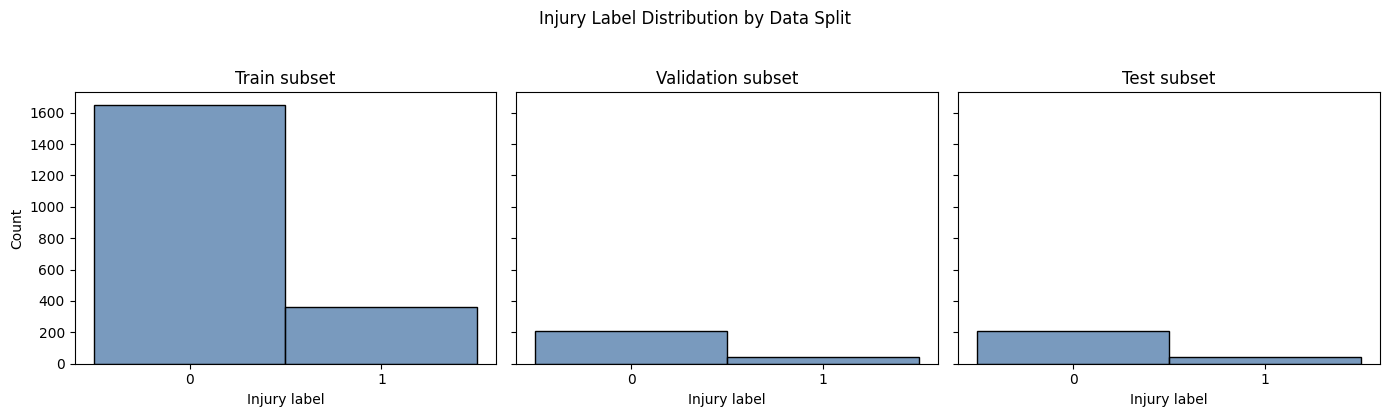

In [9]:
# Injury-label histograms for each split
label_sets = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (split_name, labels) in zip(axes, label_sets.items()):
    sns.histplot(labels, bins=[-0.5, 0.5, 1.5], discrete=True, ax=ax, color="#4C78A8")
    ax.set_title(f"{split_name} subset")
    ax.set_xlabel("Injury label")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])

plt.suptitle("Injury Label Distribution by Data Split", y=1.03)
plt.tight_layout()
plt.show()

We observed that the proportions of positive samples remains the same in all three subsets, but it is highly unbalanced, which will be considered in further model training and evaluation.

### **Model Building and Training**

In this section we will build and train our GRU model. The training includes a validation subset to regularize the generalization capacity of the model with a early-stopping mechanism to avoid overfitting. 

In [10]:
# DataLoaders (we shuffle to avoid biases)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=True)

# Build our GRU model (single GRU layer + linear layer): sequence -> binary output
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        logits = self.fc(h_n[-1])
        return logits
    
# GRU model
input_size = X_train.shape[2]
model = GRU(input_size=input_size, hidden_size=hidden_size).to(device)

# Loss function: Weighted Binary Cross Entropy (BCE) with the proportion of positives as weight
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device))

# ADAM optimized
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Function to evaluate our model (in case of validation subset)
def evaluate(loader, model, criterion, threshold=0.5):
    model.eval() # stop updating parameters, evaluation mode
    total_loss = 0.0
    total_count = 0
    all_probs = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * xb.size(0)
            total_count += yb.size(0)
            all_probs.extend(probs.cpu().numpy().flatten().tolist())
            all_true.extend(yb.cpu().numpy().astype(int).flatten().tolist())

    avg_loss = total_loss / max(total_count, 1)
    preds = (np.array(all_probs) >= threshold).astype(int) # positives will be considered those ones above the threshold
    true = np.array(all_true).astype(int)
    return avg_loss, true, np.array(all_probs), preds    

Training loops stores the update in both training and validation losses to plot their evolution over epochs. In a suitable case, both loss curves should have the same decreasing shape. However, in many cases the validation loss curve achieves a plateau while training loss curve continues to diminish. If the validation loss curve start increases, the model is overfitting and we have to trigger an early-stopping mechanism.


========== Training Simple Workflow ==========
Epoch [1/500]  Train Loss: 0.7007 | Val Loss: 0.6867 | Patience: 0/20
Epoch [2/500]  Train Loss: 0.6809 | Val Loss: 0.6682 | Patience: 0/20
Epoch [3/500]  Train Loss: 0.6615 | Val Loss: 0.6498 | Patience: 0/20
Epoch [4/500]  Train Loss: 0.6424 | Val Loss: 0.6310 | Patience: 0/20
Epoch [5/500]  Train Loss: 0.6227 | Val Loss: 0.6115 | Patience: 0/20
Epoch [6/500]  Train Loss: 0.6024 | Val Loss: 0.5909 | Patience: 0/20
Epoch [7/500]  Train Loss: 0.5806 | Val Loss: 0.5684 | Patience: 0/20
Epoch [8/500]  Train Loss: 0.5568 | Val Loss: 0.5437 | Patience: 0/20
Epoch [9/500]  Train Loss: 0.5311 | Val Loss: 0.5174 | Patience: 0/20
Epoch [10/500]  Train Loss: 0.5052 | Val Loss: 0.4920 | Patience: 0/20
Epoch [11/500]  Train Loss: 0.4814 | Val Loss: 0.4737 | Patience: 0/20
Epoch [12/500]  Train Loss: 0.4682 | Val Loss: 0.4687 | Patience: 0/20
Epoch [13/500]  Train Loss: 0.4685 | Val Loss: 0.4725 | Patience: 1/20
Epoch [14/500]  Train Loss: 0.4703 | V

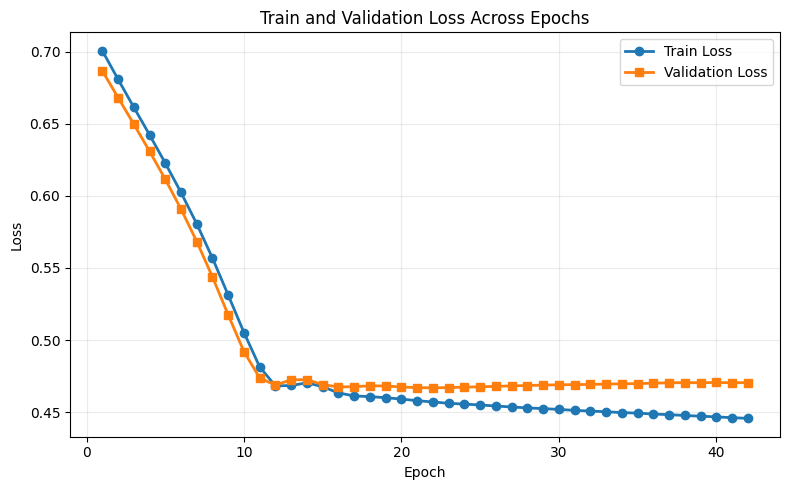

In [11]:
# Training with early stopping on validation loss. Set initial values
best_val_loss = float("inf") # start at maximum
best_state_dict = copy.deepcopy(model.state_dict()) 
patience_counter = 0

# Recorded values
train_loss_history = []
val_loss_history = []

print("\n========== Training Simple Workflow ==========%s" % "")

# Training loop
for epoch in range(epochs):
    model.train() # update parameters
    train_loss, train_total = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        train_total += yb.size(0)

    train_loss /= max(train_total, 1)

    val_loss, _, _, _ = evaluate(val_loader, model, criterion, threshold=0.5)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # Patience counter increase condition (validation loss increases)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{epochs}] ",
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Patience: {patience_counter}/{patience}"
    )

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

model.load_state_dict(best_state_dict)
torch.save(model.state_dict(), "trained_model.pt")
print("Best model saved as trained_model.pt")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, marker='o', linewidth=2, label='Train Loss')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='s', linewidth=2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Loss Across Epochs')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### **Model Evaluation**


========== Final Evaluation ==========
Best threshold (validated on validation set): 0.21
Validation balanced accuracy at best threshold: 0.6120
Test Loss: 0.4578
Test Accuracy: 0.7341
Test Balanced Accuracy: 0.6094
Test ROC AUC: 0.6477


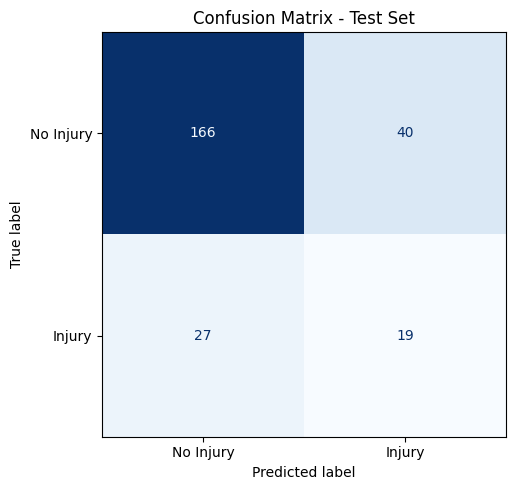

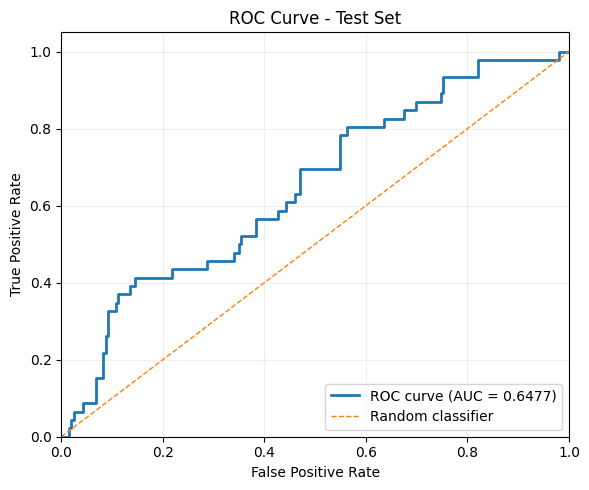

In [12]:
# Over a vast grid of thresholds, select the one maximizing balanced accuracy in validation set
threshold_grid = np.linspace(0.01, 0.99, 99)
_, y_val_true, y_val_probs, _ = evaluate(val_loader, model, criterion, threshold=0.5)
val_balanced_accuracy_scores = []

for threshold in threshold_grid:
    val_preds = (y_val_probs >= threshold).astype(int)
    val_balanced_accuracy_scores.append(balanced_accuracy_score(y_val_true, val_preds))

best_threshold = threshold_grid[int(np.argmax(val_balanced_accuracy_scores))]
best_val_balanced_accuracy = float(np.max(val_balanced_accuracy_scores))

test_loss, y_test_true, y_test_probs, y_test_pred = evaluate(
    test_loader, model, criterion, threshold=best_threshold
)

# Compute the evaluation metrics
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test_true, y_test_pred)
test_roc_auc = roc_auc_score(y_test_true, y_test_probs)
cm = confusion_matrix(y_test_true, y_test_pred)
fpr, tpr, _ = roc_curve(y_test_true, y_test_probs)
roc_auc = auc(fpr, tpr)

print("\n========== Final Evaluation ==========%s" % "")
print(f"Best threshold (validated on validation set): {best_threshold:.2f}")
print(f"Validation balanced accuracy at best threshold: {best_val_balanced_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Balanced Accuracy: {test_balanced_accuracy:.4f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Injury'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()